In [1]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import cv2


import torch, torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm, trange
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms
import torchvision.models as models

import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

from tqdm.notebook import tqdm


import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from timm import create_model
from sklearn.metrics import classification_report, confusion_matrix
import random
from PIL import Image
import os


from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns

import time
from collections import OrderedDict

import platform
import psutil

import random
import glob
from tqdm import tqdm

from PIL import Image
from torchvision import transforms
from PIL import ImageOps

from tabulate import tabulate
from torchvision import transforms


import math, random, time, copy, os, json, warnings, pathlib
from pathlib import Path
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms, datasets, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from torch.cuda.amp import autocast, GradScaler

import timm  
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Import Libraries

# 

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)

Running on cuda


# Seed Define

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"



In [4]:
!pip install torch torchvision timm matplotlib scikit-learn seaborn


In [5]:
!pip install pydicom

In [6]:
%matplotlib inline


In [7]:
# Install necessary packages
!pip install timm torch torchvision matplotlib scikit-learn seaborn pydicom

In [8]:
import os
dataset_path = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset'
print(os.listdir(dataset_path))  


['CT', 'T1-MRI', 'T2-MRI']


# Import dataset path

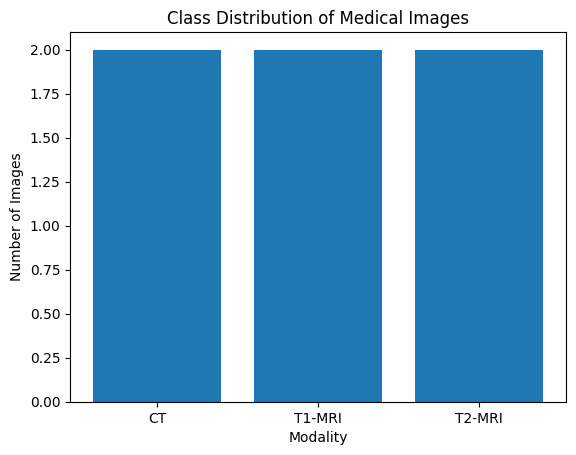

In [9]:
import matplotlib.pyplot as plt
import os

def plot_class_distribution(dataset_path):
    class_counts = {
        "CT": len([f for f in os.listdir(os.path.join(dataset_path, 'CT'))]),
        "T1-MRI": len([f for f in os.listdir(os.path.join(dataset_path, 'T1-MRI'))]),
        "T2-MRI": len([f for f in os.listdir(os.path.join(dataset_path, 'T2-MRI'))])
    }

    plt.bar(class_counts.keys(), class_counts.values())
    plt.xlabel("Modality")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution of Medical Images")
    plt.show()

# Example usage:
dataset_path = "/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset"
plot_class_distribution(dataset_path)


# Check Data Blancing

In [10]:
import os

# Define the folder paths for each modality
ct_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/CT'
t1_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI'
t2_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI'

# Function to count PNG and DICOM images in a folder
def count_images_in_folder(folder_path):
    print(f"Checking folder: {folder_path}")  # Print the folder path being checked
    png_count = 0
    dicom_count = 0
    for patient_folder in os.listdir(folder_path):
        patient_path = os.path.join(folder_path, patient_folder)
        if os.path.isdir(patient_path):  # Check if it's a folder
            print(f"Found patient folder: {patient_folder}")  # Debugging patient folder
            for subfolder in os.listdir(patient_path):  # Check inside the patient folder
                subfolder_path = os.path.join(patient_path, subfolder)
                if os.path.isdir(subfolder_path):  # Check if subfolder exists (PNG/DICOM)
                    print(f"Found subfolder: {subfolder}")  # Debugging subfolder name
                    for image_name in os.listdir(subfolder_path):  # List files in the subfolder
                        if image_name.endswith('.png'):  # Count PNG files
                            png_count += 1
                        elif image_name.endswith('.dcm'):  # Count DICOM files
                            dicom_count += 1
    return png_count, dicom_count

# Count images in each modality folder
ct_png_count, ct_dicom_count = count_images_in_folder(ct_folder)
t1_mri_png_count, t1_mri_dicom_count = count_images_in_folder(t1_mri_folder)
t2_mri_png_count, t2_mri_dicom_count = count_images_in_folder(t2_mri_folder)

# Display the image counts
print(f"Number of CT PNG images: {ct_png_count}")
print(f"Number of CT DICOM images: {ct_dicom_count}")
print(f"Number of T1-MRI PNG images: {t1_mri_png_count}")
print(f"Number of T1-MRI DICOM images: {t1_mri_dicom_count}")
print(f"Number of T2-MRI PNG images: {t2_mri_png_count}")
print(f"Number of T2-MRI DICOM images: {t2_mri_dicom_count}")


Checking folder: /kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/CT
Found patient folder: DICOM
Found subfolder: Patient_09
Found subfolder: Patient_05
Found subfolder: Patient_18
Found subfolder: Patient_03
Found subfolder: Patient_02
Found subfolder: Patient_12
Found subfolder: Patient_15
Found subfolder: Patient_10
Found subfolder: Patient_14
Found subfolder: Patient_04
Found subfolder: Patient_08
Found subfolder: Patient_11
Found subfolder: Patient_17
Found subfolder: Patient_13
Found subfolder: Patient_01
Found subfolder: Patient_07
Found subfolder: Patient_16
Found subfolder: Patient_06
Found patient folder: PNG
Found subfolder: Patient_09
Found subfolder: Patient_05
Found subfolder: Patient_18
Found subfolder: Patient_03
Found subfolder: Patient_02
Found subfolder: Patient_12
Found subfolder: Patient_15
Found subfolder: Patient_10
Found subfolder: Patient_14
Found subfolder: Patient_04
Found subfolder: Patient_08
Found subfolder: Patient_11
Found subfolder: Patient

# Image count per class 

Displaying CT image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['CT_PNG (2).png', 'CT_PNG (9).png', 'CT_PNG (12).png', 'CT_PNG (6).png', 'CT_PNG (11).png', 'CT_PNG (8).png', 'CT_PNG (3).png', 'CT_PNG (5).png', 'CT_PNG (1).png', 'CT_PNG (4).png', 'CT_PNG (10).png', 'CT_PNG (7).png']


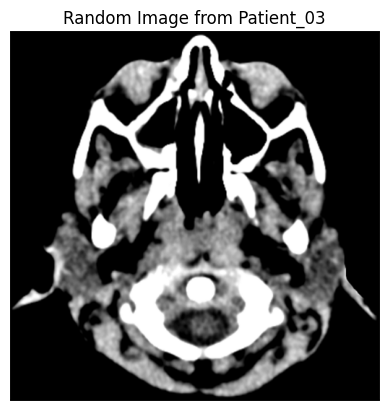

Displaying T1-MRI image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['T1_PNG (7).png', 'T1_PNG (29).png', 'T1_PNG (23).png', 'T1_PNG (17).png', 'T1_PNG (35).png', 'T1_PNG (34).png', 'T1_PNG (42).png', 'T1_PNG (13).png', 'T1_PNG (20).png', 'T1_PNG (4).png', 'T1_PNG (19).png', 'T1_PNG (8).png', 'T1_PNG (40).png', 'T1_PNG (41).png', 'T1_PNG (27).png', 'T1_PNG (16).png', 'T1_PNG (33).png', 'T1_PNG (26).png', 'T1_PNG (38).png', 'T1_PNG (37).png', 'T1_PNG (31).png', 'T1_PNG (5).png', 'T1_PNG (25).png', 'T1_PNG (6).png', 'T1_PNG (15).png', 'T1_PNG (28).png', 'T1_PNG (10).png', 'T1_PNG (11).png', 'T1_PNG (9).png', 'T1_PNG (1).png', 'T1_PNG (12).png', 'T1_PNG (21).png', 'T1_PNG (18).png', 'T1_PNG (22).png', 'T1_PNG (3).png', 'T1_PNG (36).png', 'T1

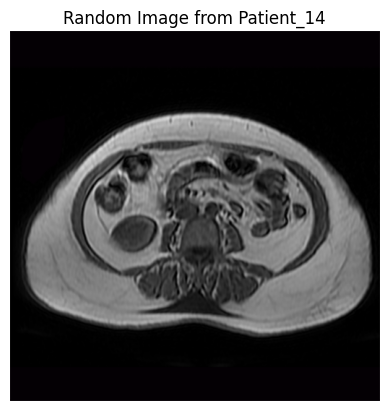

Displaying T2-MRI image:
Patient folders found: ['Patient_09', 'Patient_05', 'Patient_18', 'Patient_03', 'Patient_02', 'Patient_12', 'Patient_15', 'Patient_10', 'Patient_14', 'Patient_04', 'Patient_08', 'Patient_11', 'Patient_17', 'Patient_13', 'Patient_01', 'Patient_07', 'Patient_16', 'Patient_06']
Image files found: ['T2_PNG (12).png', 'T2_PNG (3).png', 'T2_PNG (16).png', 'T2_PNG (4).png', 'T2_PNG (6).png', 'T2_PNG (19).png', 'T2_PNG (9).png', 'T2_PNG (11).png', 'T2_PNG (14).png', 'T2_PNG (18).png', 'T2_PNG (5).png', 'T2_PNG (8).png', 'T2_PNG (17).png', 'T2_PNG (1).png', 'T2_PNG (10).png', 'T2_PNG (13).png', 'T2_PNG (2).png', 'T2_PNG (15).png', 'T2_PNG (7).png']


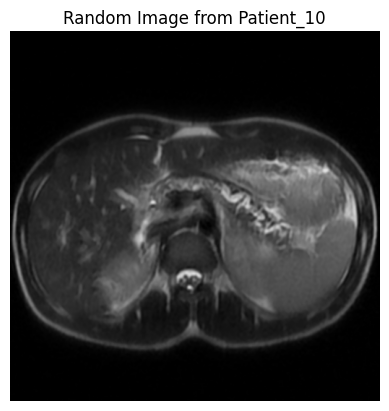

In [11]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# Function to display a random image from the PNG folder using matplotlib
def display_random_image(folder_path):
    # We assume the folder directly contains patient folders
    patient_folders = [f for f in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, f))]

    # Check if there are any patient folders in the directory
    if not patient_folders:
        print(f"No patient folders found in {folder_path}")
        return

    print(f"Patient folders found: {patient_folders}")  # Debugging patient folder names
    patient_folder = random.choice(patient_folders)  # Select a random patient folder

    # Check for image files in the patient folder (checking for PNG, JPG, and JPEG)
    subfolder_path = os.path.join(folder_path, patient_folder)
    image_files = [f for f in os.listdir(subfolder_path) if f.endswith(('.png', '.jpg', '.jpeg')) and not f.startswith('.')]

    # Debugging if no image files are found
    if not image_files:
        print(f"No image files found in {subfolder_path}")
        return

    print(f"Image files found: {image_files}")  # Debugging list of image files
    image_name = random.choice(image_files)  # Pick a random image
    image_path = os.path.join(subfolder_path, image_name)

    # Open the image
    try:
        img = Image.open(image_path)

        # Display the image using matplotlib
        plt.imshow(img)  # Display the image
        plt.axis('off')  # Turn off axis labels
        plt.title(f'Random Image from {patient_folder}')
        plt.show()

    except Exception as e:
        print(f"Error opening image {image_path}: {e}")

# Example usage for each modality
ct_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/CT/PNG' 
t1_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI/PNG'  
t2_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI/PNG' 

# Display random images for each modality
print("Displaying CT image:")
display_random_image(ct_folder)  

print("Displaying T1-MRI image:")
display_random_image(t1_mri_folder) 

print("Displaying T2-MRI image:")
display_random_image(t2_mri_folder)  


# Display Original image randomly

In [12]:
def resize_images_in_folder(folder_path, target_size=(224, 224)):
    resized_images = []
    print(f"Checking folder: {folder_path}")
    for image_name in os.listdir(folder_path):
        if image_name.endswith('.png'):  
            print(f"Processing {image_name}...") 
            image_path = os.path.join(folder_path, image_name)
            img = resize_image(image_path, target_size)
            resized_images.append(img)

    if not resized_images:
        print(f"No images resized in {folder_path}")

    return resized_images


In [13]:
import os
from PIL import Image

# Function to resize images while preserving aspect ratio and padding
def resize_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img.thumbnail(target_size, Image.Resampling.LANCZOS)  
    new_img = Image.new("RGB", target_size, (255, 255, 255))  
    img_width, img_height = img.size
    new_img.paste(img, ((target_size[0] - img_width) // 2, (target_size[1] - img_height) // 2))  
    return new_img

# Function to resize images in a folder (for each patient) and save them into respective folders
def resize_and_save_images_in_folder(folder_path, target_size=(224, 224), save_base_folder="resized_images"):
    resized_images = []  
    if not os.path.exists(save_base_folder):  
        os.makedirs(save_base_folder)

    for patient_folder in os.listdir(folder_path):
        patient_path = os.path.join(folder_path, patient_folder)
        if os.path.isdir(patient_path):
            print(f"Processing images for patient: {patient_folder}")
            # Create a subfolder for the patient inside the save folder
            patient_save_folder = os.path.join(save_base_folder, patient_folder)
            if not os.path.exists(patient_save_folder):  
                os.makedirs(patient_save_folder)

            for image_name in os.listdir(patient_path):
                if image_name.endswith('.png'):  
                    image_path = os.path.join(patient_path, image_name)
                    resized_image = resize_image(image_path, target_size)
                    resized_images.append(resized_image) 

                    # Save the resized image to the patient's subfolder
                    save_path = os.path.join(patient_save_folder, image_name)
                    resized_image.save(save_path)
                    print(f"Processed and saved: {image_name}")

    return resized_images 


ct_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/CT/PNG' 
t1_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T1-MRI/PNG'  
t2_mri_folder = '/kaggle/input/ctmri2/Paired MRI (T1, T2) and CT Scans Dataset/T2-MRI/PNG' 

save_base_folder = '/kaggle/working/ResizedImages'


ct_images = resize_and_save_images_in_folder(ct_folder, save_base_folder=os.path.join(save_base_folder, 'CT'))
t1_mri_images = resize_and_save_images_in_folder(t1_mri_folder, save_base_folder=os.path.join(save_base_folder, 'T1-MRI'))
t2_mri_images = resize_and_save_images_in_folder(t2_mri_folder, save_base_folder=os.path.join(save_base_folder, 'T2-MRI'))



Processing images for patient: Patient_09
Processed and saved: CT_PNG (2).png
Processed and saved: CT_PNG (9).png
Processed and saved: CT_PNG (12).png
Processed and saved: CT_PNG (6).png
Processed and saved: CT_PNG (11).png
Processed and saved: CT_PNG (8).png
Processed and saved: CT_PNG (16).png
Processed and saved: CT_PNG (13).png
Processed and saved: CT_PNG (3).png
Processed and saved: CT_PNG (5).png
Processed and saved: CT_PNG (20).png
Processed and saved: CT_PNG (1).png
Processed and saved: CT_PNG (4).png
Processed and saved: CT_PNG (17).png
Processed and saved: CT_PNG (19).png
Processed and saved: CT_PNG (14).png
Processed and saved: CT_PNG (10).png
Processed and saved: CT_PNG (7).png
Processed and saved: CT_PNG (15).png
Processed and saved: CT_PNG (18).png
Processing images for patient: Patient_05
Processed and saved: CT_PNG (2).png
Processed and saved: CT_PNG (9).png
Processed and saved: CT_PNG (12).png
Processed and saved: CT_PNG (6).png
Processed and saved: CT_PNG (11).png
Pro

# Resize image and saved them 

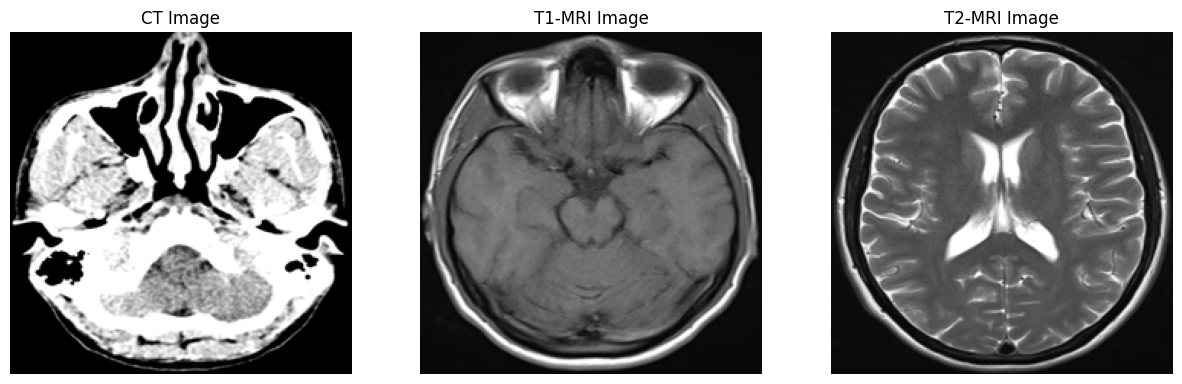

In [14]:
import numpy as np
import matplotlib.pyplot as plt


def display_images_horizontally(images, titles=None):
  
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

    if titles is None:
        titles = ['Image'] * len(images)  

    for i, (img, ax) in enumerate(zip(images, axes)):
       
        ax.imshow(np.array(img), cmap='gray')  
        ax.set_title(titles[i])
        ax.axis('off')  

    plt.show()  

display_images_horizontally([ct_images[0], t1_mri_images[0], t2_mri_images[0]],
                            titles=["CT Image", "T1-MRI Image", "T2-MRI Image"])

# Displaying images per class after resized 

In [15]:
import os


resized_images_path = '/kaggle/working/ResizedImages'


# List the files in each directory
print(f"Files in {resized_images_path}: {os.listdir(resized_images_path)}")



Files in /kaggle/working/ResizedImages: ['CT', 'T2-MRI', 'T1-MRI']


# Saved images after resize per class

Modality: CT
  Patient: Patient_01
  Patient: Patient_02
  Patient: Patient_03
  Patient: Patient_04
  Patient: Patient_05
  Patient: Patient_06
  Patient: Patient_07
  Patient: Patient_08
  Patient: Patient_09
  Patient: Patient_10
  Patient: Patient_11
  Patient: Patient_12
  Patient: Patient_13
  Patient: Patient_14
  Patient: Patient_15
  Patient: Patient_16
  Patient: Patient_17
  Patient: Patient_18
Modality: T1-MRI
  Patient: Patient_01
  Patient: Patient_02
  Patient: Patient_03
  Patient: Patient_04
  Patient: Patient_05
  Patient: Patient_06
  Patient: Patient_07
  Patient: Patient_08
  Patient: Patient_09
  Patient: Patient_10
  Patient: Patient_11
  Patient: Patient_12
  Patient: Patient_13
  Patient: Patient_14
  Patient: Patient_15
  Patient: Patient_16
  Patient: Patient_17
  Patient: Patient_18
Modality: T2-MRI
  Patient: Patient_01
  Patient: Patient_02
  Patient: Patient_03
  Patient: Patient_04
  Patient: Patient_05
  Patient: Patient_06
  Patient: Patient_07
  Patie

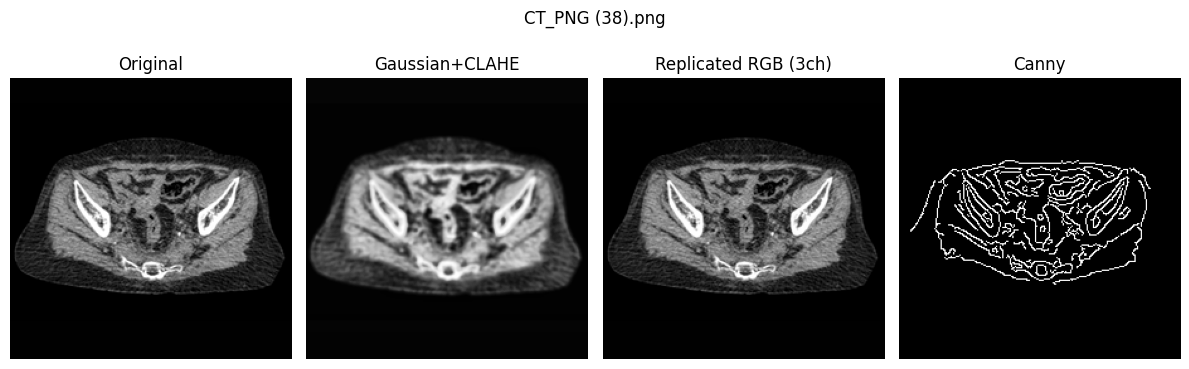

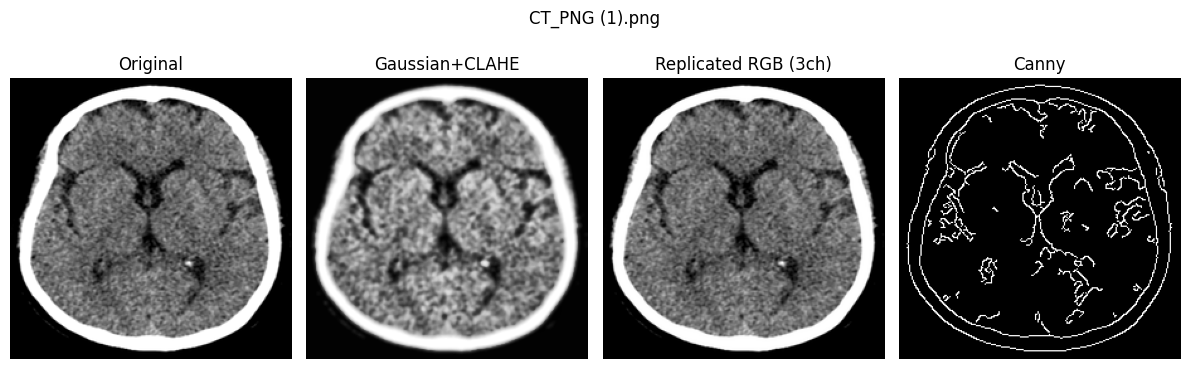

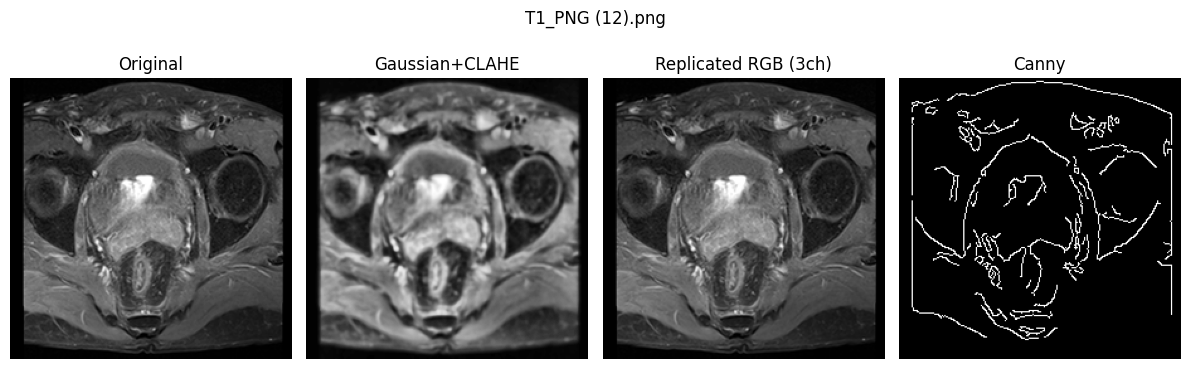

In [16]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import random
random.seed(42)

# ---------- Filters ----------
def apply_gaussian_filter(image, ksize=(5, 5), sigma=0):
    return cv2.GaussianBlur(image, ksize, sigma)

def apply_clahe(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)

def convert_to_rgb3ch(image):
    # replicate single-channel grayscale to 3 channels
    return np.stack([image] * 3, axis=-1)

def apply_canny(image, low=100, high=200):
    # Canny expects a single-channel uint8 image
    return cv2.Canny(image, low, high)

# ---------- Viz ----------
def show_four(original, clahe_img, rgb3ch_img, canny_img, title=""):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1); plt.imshow(original, cmap='gray'); plt.title("Original"); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(clahe_img, cmap='gray'); plt.title("Gaussian+CLAHE"); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(cv2.cvtColor(rgb3ch_img, cv2.COLOR_BGR2RGB)); plt.title("Replicated RGB (3ch)"); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(canny_img, cmap='gray'); plt.title("Canny"); plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

# ---------- Processing ----------
def process_images_all(base_folder, save_base_folder, num_show=3):
    if not os.path.exists(base_folder):
        print(f"Error: base folder not found: {base_folder}")
        return

    os.makedirs(save_base_folder, exist_ok=True)
    saved = []  # collect paths for random display

    for modality in sorted(os.listdir(base_folder)):
        modality_path = os.path.join(base_folder, modality)
        if not os.path.isdir(modality_path):
            continue

        print(f"Modality: {modality}")
        save_modality = os.path.join(save_base_folder, modality)
        os.makedirs(save_modality, exist_ok=True)

        for patient in sorted(os.listdir(modality_path)):
            patient_path = os.path.join(modality_path, patient)
            if not os.path.isdir(patient_path):
                continue

            print(f"  Patient: {patient}")
            save_patient = os.path.join(save_modality, patient)
            os.makedirs(save_patient, exist_ok=True)

            for image_name in sorted(os.listdir(patient_path)):
                if not image_name.lower().endswith(".png"):
                    continue

                img_path = os.path.join(patient_path, image_name)
                if not os.path.isfile(img_path):
                    continue

                # read grayscale
                gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if gray is None:
                    print(f"    Failed to read {img_path}")
                    continue

                # pipeline
                gblur  = apply_gaussian_filter(gray, (5, 5), 0)
                clahe  = apply_clahe(gblur, clip_limit=2.0, tile_grid_size=(8, 8))
                rgb3ch = convert_to_rgb3ch(gray)         
                canny  = apply_canny(gblur, 100, 200)   

                # save
                path_clahe  = os.path.join(save_patient, f"clahe_{image_name}")
                path_rgb3ch = os.path.join(save_patient, f"rgb3ch_{image_name}")
                path_canny  = os.path.join(save_patient, f"canny_{image_name}")

                ok1 = cv2.imwrite(path_clahe, clahe)
                ok2 = cv2.imwrite(path_rgb3ch, rgb3ch)   
                ok3 = cv2.imwrite(path_canny, canny)

                if ok1 and ok2 and ok3:
                    saved.append((img_path, path_clahe, path_rgb3ch, path_canny))
                else:
                    print(f"    Save error on {image_name}")

    # show random N examples
    if saved:
        print(f"\nShowing {min(num_show, len(saved))} random results…")
        for paths in random.sample(saved, k=min(num_show, len(saved))):
            orig_p, clahe_p, rgb3ch_p, canny_p = paths
            orig   = cv2.imread(orig_p, cv2.IMREAD_GRAYSCALE)
            clahe  = cv2.imread(clahe_p, cv2.IMREAD_GRAYSCALE)
            rgb3ch = cv2.imread(rgb3ch_p)                 
            canny  = cv2.imread(canny_p, cv2.IMREAD_GRAYSCALE)
            if orig is not None and clahe is not None and rgb3ch is not None and canny is not None:
                title = os.path.basename(orig_p)
                show_four(orig, clahe, rgb3ch, canny, title=title)
    else:
        print("No images processed (nothing to display).")

# ---------- Run ----------
base_folder = "/kaggle/working/ResizedImages"            
save_folder = "/kaggle/working/Processed_Images_All"     
process_images_all(base_folder, save_folder, num_show=3)


# Image Pre-processed and Display Randomly

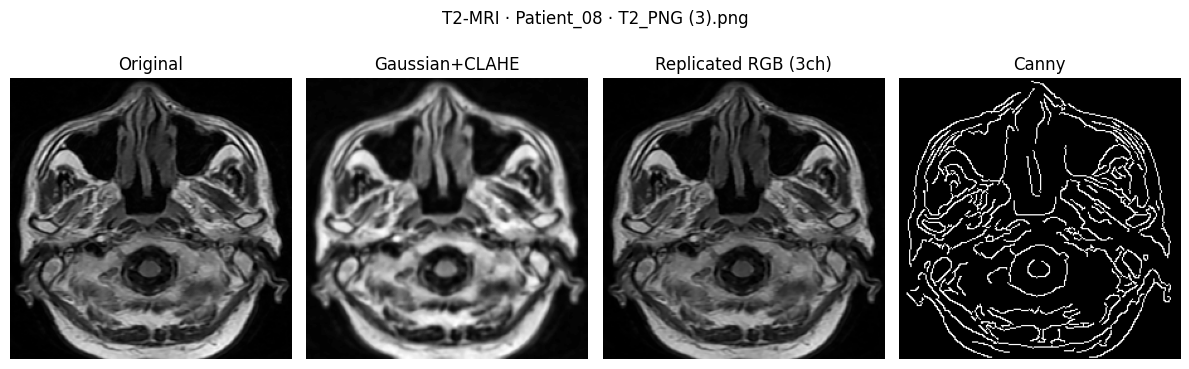

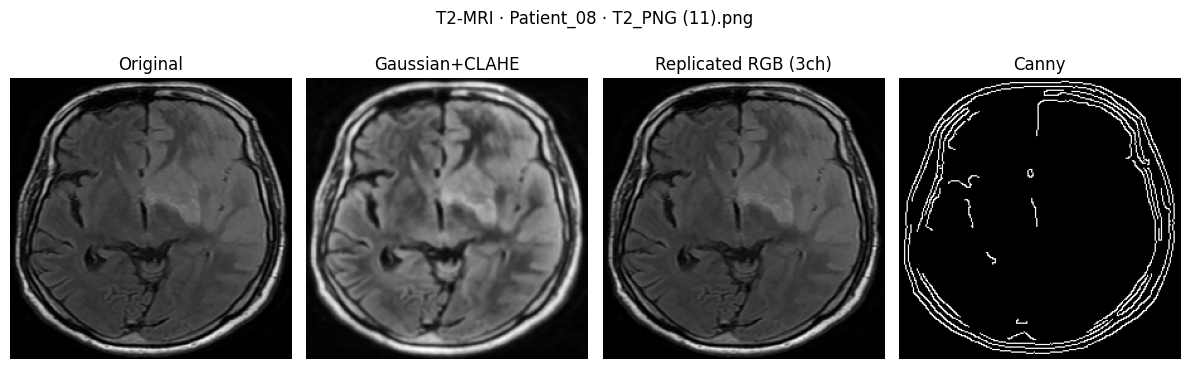

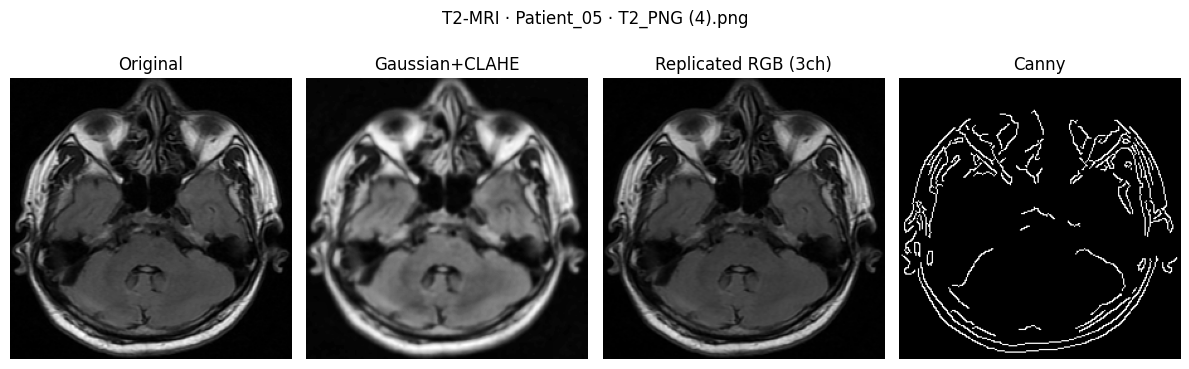

In [17]:
import os, cv2, random, glob

def show_t2(n=3):
    base_root = "/kaggle/working/ResizedImages"
    proc_root = "/kaggle/working/Processed_Images_All"

    originals = sorted(glob.glob(os.path.join(base_root, "T2-MRI", "*", "*.png")))
    if not originals:
        print("No T2 originals found."); return

    picks = random.sample(originals, min(n, len(originals)))
    for src in picks:
        patient = os.path.basename(os.path.dirname(src))
        base = os.path.splitext(os.path.basename(src))[0]  # e.g., "T2_PNG (1)"

        proc_dir = os.path.join(proc_root, "T2-MRI", patient)
        p_clahe  = os.path.join(proc_dir, f"clahe_{base}.png")
        p_rgb3   = os.path.join(proc_dir, f"rgb3ch_{base}.png")
        p_canny  = os.path.join(proc_dir, f"canny_{base}.png")

        gray  = cv2.imread(src, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.imread(p_clahe, cv2.IMREAD_GRAYSCALE)  if os.path.exists(p_clahe)  else apply_clahe(apply_gaussian_filter(gray))
        rgb3  = cv2.imread(p_rgb3)                         if os.path.exists(p_rgb3)   else convert_to_rgb3ch(gray)
        canny = cv2.imread(p_canny, cv2.IMREAD_GRAYSCALE)  if os.path.exists(p_canny)  else apply_canny(apply_gaussian_filter(gray))

        show_four(gray, clahe, rgb3, canny, title=f"T2-MRI · {patient} · {os.path.basename(src)}")

show_t2(3)


# T2-MRI images after pre-processiong 

In [18]:
import os
import cv2

# Path to the processed images folder
processed_images_path = '/kaggle/working/Processed_Images_All'

# Loop through the files in the folder and get the image size
for modality_folder in os.listdir(processed_images_path):
    modality_path = os.path.join(processed_images_path, modality_folder)
    
    if os.path.isdir(modality_path):  # Process only folders
        for patient_folder in os.listdir(modality_path):
            patient_path = os.path.join(modality_path, patient_folder)
            
            if os.path.isdir(patient_path):  # Process only patient folders
                for image_name in os.listdir(patient_path):
                    image_path = os.path.join(patient_path, image_name)
                    
                    if image_name.endswith('.png') and os.path.isfile(image_path):
                        # Read the image using OpenCV
                        image = cv2.imread(image_path)
                        
                        if image is not None:
                            height, width = image.shape[:2] 
                            print(f"Image: {image_name}, Size: {width}x{height}")
                        else:
                            print(f"Failed to load image {image_name}")


Image: clahe_CT_PNG (2).png, Size: 224x224
Image: rgb3ch_CT_PNG (32).png, Size: 224x224
Image: canny_CT_PNG (26).png, Size: 224x224
Image: rgb3ch_CT_PNG (22).png, Size: 224x224
Image: canny_CT_PNG (31).png, Size: 224x224
Image: canny_CT_PNG (4).png, Size: 224x224
Image: rgb3ch_CT_PNG (24).png, Size: 224x224
Image: canny_CT_PNG (30).png, Size: 224x224
Image: clahe_CT_PNG (1).png, Size: 224x224
Image: clahe_CT_PNG (23).png, Size: 224x224
Image: canny_CT_PNG (19).png, Size: 224x224
Image: canny_CT_PNG (1).png, Size: 224x224
Image: clahe_CT_PNG (31).png, Size: 224x224
Image: rgb3ch_CT_PNG (38).png, Size: 224x224
Image: rgb3ch_CT_PNG (11).png, Size: 224x224
Image: canny_CT_PNG (9).png, Size: 224x224
Image: clahe_CT_PNG (42).png, Size: 224x224
Image: rgb3ch_CT_PNG (36).png, Size: 224x224
Image: rgb3ch_CT_PNG (28).png, Size: 224x224
Image: canny_CT_PNG (21).png, Size: 224x224
Image: rgb3ch_CT_PNG (20).png, Size: 224x224
Image: clahe_CT_PNG (11).png, Size: 224x224
Image: canny_CT_PNG (13).png,

# Check Dataset Resized or Not 

In [19]:
# ============================================================
# 1 · Paths & Transforms
# ============================================================
data_dir = '/kaggle/working/Processed_Images_All' 

# • base_tf  : used for val/test
# • weak_tf  : light aug for pseudo-labelling
# • strong_tf: heavy aug for consistency loss

base_tf   = transforms.Compose([
     
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
weak_tf   = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.RandomRotation(20),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
strong_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandAugment(2, 10),
    transforms.RandomCrop(224, padding=4),
    transforms.ToTensor(),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.1)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Paths & Transforms and Weak and strong Augmentation

In [20]:
# dataset (weak + strong augmentations) 

class UnlabeledPair(Dataset):
    def __init__(self, base_dataset, weak_tf, strong_tf):
        self.base_dataset = base_dataset
        self.weak_tf = weak_tf
        self.strong_tf = strong_tf

    def __getitem__(self, idx):
        img, _ = self.base_dataset[idx]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        return self.weak_tf(img), self.strong_tf(img)

    def __len__(self):
        return len(self.base_dataset)

#  UnlabeledPair based on dataset (weak + strong augmentations)

In [21]:
# Build splits: (train_labeled, train_unlabeled, val)

FULL = datasets.ImageFolder(data_dir)

# ----  extract labels for stratified splitting   ------

labels = [lbl for _, lbl in FULL.samples]
labels = np.array(labels)

# --- split into training and validation sets (80% train, 20% val) ---
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))
train_labels = labels[train_idx]

# --- split training set into labeled  and unlabeled (20% labeled) ---
p_labeled = 0.20
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=1 - p_labeled,
                              random_state=SEED)
lab_idx, unlab_idx = next(sss2.split(np.zeros(len(train_labels)), train_labels))

lab_idx   = train_idx[lab_idx]
unlab_idx = train_idx[unlab_idx]

# ---------- labelled ----------
train_lab_ds = Subset(
    datasets.ImageFolder(data_dir, transform=weak_tf),
    lab_idx)

# ---------- unlabeled ----------
base_unlab   = Subset(
    datasets.ImageFolder(data_dir),        # ← NO transform
    unlab_idx)

# wrap with UnlabeledPair to apply weak and strong augmentations

train_unlab_ds = UnlabeledPair(base_unlab, weak_tf, strong_tf)

# ---------- validation ----------
val_ds = Subset(
    datasets.ImageFolder(data_dir, transform=base_tf), val_idx)

# ---------- create data loaders ----------
BATCH_L = 2
BATCH_U = 4
lab_loader   = DataLoader(train_lab_ds,   batch_size=BATCH_L,
                          shuffle=True,  drop_last=True,  num_workers=2)
unlab_loader = DataLoader(train_unlab_ds, batch_size=BATCH_U,
                          shuffle=True,  drop_last=True,  num_workers=2)
val_loader   = DataLoader(val_ds,         batch_size=8,
                          shuffle=True, num_workers=2)

# Data Spliting

In [22]:
import timm

# List ViT-Small (patch16, 224) variants that have pretrained weights
vit_small_224 = timm.list_models('vit_small_patch16_224*', pretrained=True)
print("Available ViT-Small 224 models:\n", vit_small_224)

# Check if the AugReg-21k variant exists in this timm build
target = 'vit_small_patch16_224.augreg_in21k'
print(f"\nHas '{target}'? ", target in vit_small_224)


Available ViT-Small 224 models:
 ['vit_small_patch16_224.augreg_in1k', 'vit_small_patch16_224.augreg_in21k', 'vit_small_patch16_224.augreg_in21k_ft_in1k', 'vit_small_patch16_224.dino']

Has 'vit_small_patch16_224.augreg_in21k'?  True


# Import ViTSmall Model

In [23]:
class LinearHead(nn.Module):
    def __init__(self, in_features, num_classes=3):
        super().__init__()
        self.classifier = nn.Linear(in_features, num_classes)
    def forward(self, x):
        return self.classifier(x)

class ViTSmallBackbone(nn.Module):
    def __init__(self, num_classes=3, dropout=0.15, use_augreg=True, grad_ckpt=True):
        super().__init__()
        name = 'vit_small_patch16_224.augreg_in21k' if use_augreg else 'vit_small_patch16_224'
        try:
            self.backbone = timm.create_model(name, pretrained=True, num_classes=0)
        except Exception:
            self.backbone = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

        if grad_ckpt and hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)

        for p in self.backbone.parameters():
            p.requires_grad = False

        in_feats = self.backbone.num_features  
        self.dropout = nn.Dropout(dropout)
        self.head = LinearHead(in_features=in_feats, num_classes=num_classes)

    def forward(self, x):
        feats = self.backbone(x)          
        return self.head(self.dropout(feats))

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True


# Linear Head and ViTSmall Backbone

In [24]:
import torch
import torch.nn as nn
import timm

# --- ViT-Small (AugReg-21k) Backbone + Linear Head wrapped for Mean Teacher ---
class ViTSmallMeanTeacherModel(nn.Module):
    def __init__(self, num_classes=3, use_augreg=True, freeze_backbone=True, grad_ckpt=True):
        super().__init__()
        name = 'vit_small_patch16_224.augreg_in21k' if use_augreg else 'vit_small_patch16_224'
        try:
            # num_classes=0 → feature extractor (returns [B, C] embedding)
            self.backbone = timm.create_model(name, pretrained=True, num_classes=0)
        except Exception as e:
            print("AugReg weights not found, falling back to IN1k:", e)
            self.backbone = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

        if grad_ckpt and hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)

        self.freeze_backbone = freeze_backbone
        for p in self.backbone.parameters():
            p.requires_grad = not freeze_backbone

        in_feats = self.backbone.num_features  
        self.head = LinearHead(in_features=in_feats, num_classes=num_classes)

    def forward(self, x):
        # For Mean Teacher "teacher" behavior, keep backbone frozen/no-grad
        if self.freeze_backbone:
            with torch.no_grad():
                feats = self.backbone(x)
        else:
            feats = self.backbone(x)
        return self.head(feats)

    def unfreeze_backbone(self):
        self.freeze_backbone = False
        for p in self.backbone.parameters():
            p.requires_grad = True


# ViT-Small (AugReg-21k) Backbone + Linear Head wrapped

In [25]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- ViT-Small (AugReg-21k) backbone (feature extractor) ---
class ViTSmallBackbone(nn.Module):
    def __init__(self, num_classes=0, use_augreg=True, freeze=True, grad_ckpt=True):
        super().__init__()
        name = 'vit_small_patch16_224.augreg_in21k' if use_augreg else 'vit_small_patch16_224'
        try:
            # num_classes=0 -> return [B, C] features (no classifier head)
            self.backbone = timm.create_model(name, pretrained=True, num_classes=num_classes)
        except Exception as e:
            print("AugReg weights not found, falling back to IN1k:", e)
            self.backbone = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=num_classes)

        if grad_ckpt and hasattr(self.backbone, "set_grad_checkpointing"):
            self.backbone.set_grad_checkpointing(True)

        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        return self.backbone(x)  # [B, 384] for ViT-S

# --- Linear head for classification ---
class LinearHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.classifier(x)

# --- Full Mean-Teacher wrapper using ViT-S backbone ---
class ViTSmallMeanTeacherModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = ViTSmallBackbone(num_classes=0, use_augreg=True, freeze=True)
        in_feats = self.backbone.backbone.num_features  # 384 for ViT-S
        self.head = LinearHead(in_features=in_feats, num_classes=num_classes)

    def forward(self, x):
        feats = self.backbone(x)   
        return self.head(feats)   

# ---- Instantiate student & teacher ----
num_classes = 3
student = ViTSmallMeanTeacherModel(num_classes).to(device)
teacher = ViTSmallMeanTeacherModel(num_classes).to(device)

# Teacher params should not get gradients
for p in teacher.parameters():
    p.requires_grad = False

# Initialize teacher from student
teacher.load_state_dict(student.state_dict())

# EMA update (Mean Teacher)
ema_decay = 0.995  # typical: 0.99–0.999
def update_ema(student_model, teacher_model, decay):
    with torch.no_grad():
        for s, t in zip(student_model.parameters(), teacher_model.parameters()):
            t.data.mul_(decay).add_(s.data, alpha=1.0 - decay)


# ViT-Small (AugReg-21k) backbone (feature extractor),Full Mean-Teacher wrapper using ViT-S backbone

In [26]:
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import math, numpy as np, torch, torch.nn as nn

EPOCHS = 100  

# ---- loss & optimizer ----
class_weights = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32, device=device)  # len == num_classes
criterion_sup = nn.CrossEntropyLoss(weight=class_weights)
opt = torch.optim.AdamW(student.parameters(), lr=5e-5, weight_decay=0.05)

# Cosine LR over the whole run
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=5e-6)

def sigmoid_rampup(current, rampup_length):
    if rampup_length == 0: return 1.0
    current = np.clip(current, 0.0, rampup_length)
    phase = 1.0 - current / rampup_length
    return float(math.exp(-5.0 * phase * phase))

# ---- evaluation ----
def evaluate_model(model, loader):
    model.eval()
    all_p, all_t = [], []
    device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
    with torch.inference_mode(), torch.amp.autocast(device_type):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds  = logits.argmax(1)
            all_p.append(preds.cpu().numpy())
            all_t.append(y.cpu().numpy())

    y_pred = np.concatenate(all_p); y_true = np.concatenate(all_t)
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(classification_report(
        y_true, y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names, digits=3, zero_division=0
    ))
    return acc, pr, rc, f1


# Evaluation

In [27]:
class_names = ['CT', 'T1-MRI', 'T2-MRI']

# Class Name Define

In [28]:
import json, copy
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

best_f1, best_state = 0.0, None
history = []
train_loss_list, val_loss_list = [], []

EPOCHS = 100
lambda_max = 30.0
ramp_len  = 4

# AMP (new API)
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
scaler = GradScaler(device_type)

# Ensure models/criterion on device
student = student.to(device)
teacher = teacher.to(device)
teacher.eval()                 # teacher stays in eval (dropout off)
teacher.requires_grad_(False)  # teacher never needs grads (EMA only)
criterion_sup = criterion_sup.to(device)

epoch_results = []

best_val_loss = float('inf')   # just for logging; no early stop

for epoch in range(1, EPOCHS + 1):
    student.train()
    lab_iter, unlab_iter = iter(lab_loader), iter(unlab_loader)
    n_steps = max(len(lab_loader), len(unlab_loader))
    total_loss = 0.0

    pbar = tqdm(range(n_steps), desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for _ in pbar:
        try:
            x_lab, y_lab = next(lab_iter)
        except StopIteration:
            lab_iter = iter(lab_loader); x_lab, y_lab = next(lab_iter)
        try:
            x_w, x_s = next(unlab_iter)
        except StopIteration:
            unlab_iter = iter(unlab_loader); x_w, x_s = next(unlab_iter)

        x_lab, y_lab = x_lab.to(device), y_lab.to(device)
        x_w, x_s     = x_w.to(device), x_s.to(device)

        opt.zero_grad(set_to_none=True)

        with autocast(device_type=device_type):
            # supervised loss (student)
            logits_lab = student(x_lab)
            loss_sup   = criterion_sup(logits_lab, y_lab)

            # teacher targets on weak views (no grad)
            with torch.no_grad():
                t_prob = F.softmax(teacher(x_w), dim=1)

            # student predictions on strong views
            s_prob    = F.softmax(student(x_s), dim=1)
            loss_cons = F.mse_loss(s_prob, t_prob)

            lam  = lambda_max * sigmoid_rampup(epoch - 1, ramp_len)
            loss = loss_sup + lam * loss_cons

        scaler.scale(loss).backward()
        # torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)  # optional
        scaler.step(opt)
        scaler.update()

        # EMA update of teacher weights
        update_ema(student, teacher, ema_decay)

        total_loss += float(loss.item())
        pbar.set_postfix(sup=float(loss_sup.item()),
                         cons=float(loss_cons.item()),
                         lam=float(lam))

    avg_train_loss = total_loss / max(1, n_steps)
    train_loss_list.append(avg_train_loss)

    # ---- validation (teacher) ----
    teacher.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = teacher(x)
            val_loss += float(criterion_sup(logits, y).item())
    val_loss /= max(1, len(val_loader))
    val_loss_list.append(val_loss)

    acc, pr, rc, f1 = evaluate_model(teacher, val_loader)
    history.append(dict(epoch=epoch, acc=acc, prec=pr, rec=rc, f1=f1))

    epoch_results.append({
        'epoch': epoch,
        'train_loss': avg_train_loss,
        'val_loss':   val_loss,
        'val_acc':    acc,
        'f1_score':   f1
    })

    # track bests (no stopping)
    best_val_loss = min(best_val_loss, val_loss)
    if f1 > best_f1:
        best_f1 = f1
        best_state = copy.deepcopy(teacher.state_dict())
        torch.save(best_state, "best_mean_teacher.pth")

    # step LR scheduler
    sched.step()

print("\nEpoch Summary after all epochs:")
for r in epoch_results:
    print(f"Epoch {r['epoch']:02d}: train_loss={r['train_loss']:.4f} "
          f"val_loss={r['val_loss']:.4f} val_acc={r['val_acc']:.4f} F1={r['f1_score']:.4f}")

print(f"\nBest F1 = {best_f1:.4f}")

with open("history.json", "w") as f:
    json.dump(history, f, indent=2)


              precision    recall  f1-score   support

          CT      0.576     0.210     0.308       233
      T1-MRI      0.425     0.363     0.392       234
      T2-MRI      0.365     0.650     0.468       234

    accuracy                          0.408       701
   macro avg      0.456     0.408     0.389       701
weighted avg      0.455     0.408     0.389       701



              precision    recall  f1-score   support

          CT      0.818     0.558     0.663       233
      T1-MRI      0.532     0.389     0.449       234
      T2-MRI      0.445     0.705     0.545       234

    accuracy                          0.551       701
   macro avg      0.598     0.551     0.553       701
weighted avg      0.598     0.551     0.553       701



              precision    recall  f1-score   support

          CT      0.867     0.730     0.793       233
      T1-MRI      0.656     0.449     0.533       234
      T2-MRI      0.504     0.744     0.601       234

    accuracy                          0.641       701
   macro avg      0.676     0.641     0.642       701
weighted avg      0.676     0.641     0.642       701



              precision    recall  f1-score   support

          CT      0.882     0.803     0.840       233
      T1-MRI      0.715     0.590     0.646       234
      T2-MRI      0.564     0.714     0.630       234

    accuracy                          0.702       701
   macro avg      0.720     0.702     0.706       701
weighted avg      0.720     0.702     0.705       701



              precision    recall  f1-score   support

          CT      0.838     0.824     0.831       233
      T1-MRI      0.711     0.568     0.632       234
      T2-MRI      0.558     0.679     0.613       234

    accuracy                          0.690       701
   macro avg      0.703     0.691     0.692       701
weighted avg      0.702     0.690     0.692       701



...

              precision    recall  f1-score   support

          CT      0.894     0.828     0.860       233
      T1-MRI      0.730     0.671     0.699       234
      T2-MRI      0.596     0.688     0.639       234

    accuracy                          0.729       701
   macro avg      0.740     0.729     0.733       701
weighted avg      0.740     0.729     0.732       701



              precision    recall  f1-score   support

          CT      0.902     0.828     0.864       233
      T1-MRI      0.730     0.671     0.699       234
      T2-MRI      0.596     0.692     0.640       234

    accuracy                          0.730       701
   macro avg      0.743     0.731     0.734       701
weighted avg      0.742     0.730     0.734       701



              precision    recall  f1-score   support

          CT      0.901     0.824     0.861       233
      T1-MRI      0.746     0.667     0.704       234
      T2-MRI      0.595     0.709     0.647       234

    accuracy                          0.733       701
   macro avg      0.748     0.733     0.737       701
weighted avg      0.747     0.733     0.737       701



              precision    recall  f1-score   support

          CT      0.901     0.824     0.861       233
      T1-MRI      0.741     0.671     0.704       234
      T2-MRI      0.591     0.697     0.639       234

    accuracy                          0.730       701
   macro avg      0.744     0.731     0.735       701
weighted avg      0.744     0.730     0.735       701



              precision    recall  f1-score   support

          CT      0.902     0.828     0.864       233
      T1-MRI      0.751     0.671     0.709       234
      T2-MRI      0.597     0.709     0.648       234

    accuracy                          0.736       701
   macro avg      0.750     0.736     0.740       701
weighted avg      0.750     0.736     0.740       701


Epoch Summary after all epochs:
Epoch 01: train_loss=1.1638 val_loss=1.0404 val_acc=0.4080 F1=0.3892
Epoch 02: train_loss=0.9678 val_loss=0.8571 val_acc=0.5506 F1=0.5527
Epoch 03: train_loss=1.0441 val_loss=0.7654 val_acc=0.6405 F1=0.6422
Epoch 04: train_loss=1.2858 val_loss=0.7299 val_acc=0.7019 F1=0.7057
Epoch 05: train_loss=1.3890 val_loss=0.7147 val_acc=0.6904 F1=0.6919
Epoch 06: train_loss=1.2646 val_loss=0.7135 val_acc=0.6733 F1=0.6770
Epoch 07: train_loss=1.2090 val_loss=0.6981 val_acc=0.6776 F1=0.6791
Epoch 08: train_loss=1.1838 val_loss=0.6874 val_acc=0.6805 F1=0.6823
Epoch 09: train_loss=1.1404 val_lo

# Model Train

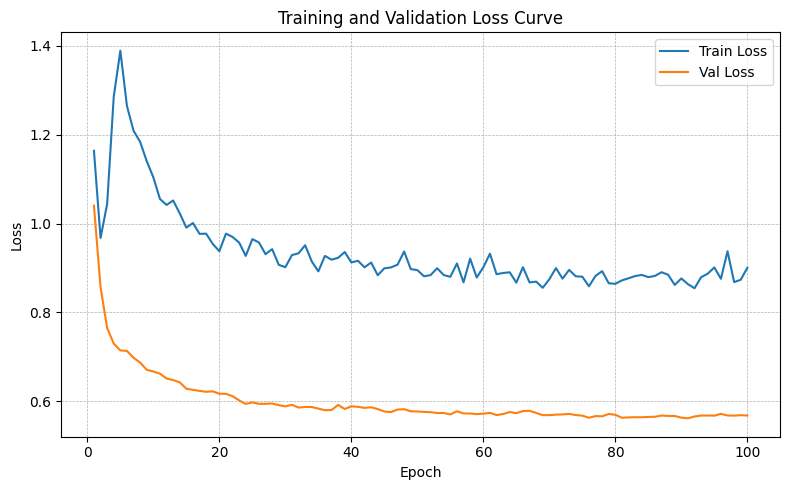

In [34]:
import matplotlib.pyplot as plt

n = min(len(train_loss_list), len(val_loss_list))
epochs = range(1, n + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_list[:n], label="Train Loss")
plt.plot(epochs, val_loss_list[:n], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve")
plt.legend()
plt.grid(True, ls="--", lw=0.5)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()


# Loss Curv

In [35]:
import json

try:
    with open("history.json", "r") as f:
        history = json.load(f)
except (FileNotFoundError, json.JSONDecodeError):
    history = []

if not isinstance(history, list) or not history:
    print("No history found.")
else:
    best = max(history, key=lambda x: x.get('f1', float('-inf')))
    print(
        f"Best epoch: {best.get('epoch', '?')} | "
        f"F1 = {best.get('f1', 0):.4f} | "
        f"Acc = {best.get('acc', 0):.4f} | "
        f"Prec = {best.get('prec', 0):.4f} | "
        f"Rec = {best.get('rec', 0):.4f}"
    )


Best epoch: 100 | F1 = 0.7403 | Acc = 0.7361 | Prec = 0.7501 | Rec = 0.7362


# Best Epoch and F1 Score

In [36]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

def evaluate_model(model, loader, class_names=None, device=None, use_amp=True, verbose=True):
    device = device or next(model.parameters()).device
    model.eval()

    y_true_chunks, y_pred_chunks = [], []
    device_type = 'cuda' if device.type == 'cuda' else 'cpu'

    with torch.inference_mode(), torch.amp.autocast(device_type, enabled=use_amp and device_type=='cuda'):
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            logits = model(x)
            preds  = logits.argmax(dim=1)
            y_true_chunks.append(y.cpu().numpy())
            y_pred_chunks.append(preds.cpu().numpy())

    if not y_true_chunks:
        raise ValueError("Empty dataloader — no batches to evaluate.")

    y_true = np.concatenate(y_true_chunks)
    y_pred = np.concatenate(y_pred_chunks)

    # Overall metrics (macro = treats classes equally)
    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    if verbose:
        print("\nOverall Metrics:")
        print(f"Accuracy : {acc:.4f}")
        print(f"Precision: {pr:.4f}")
        print(f"Recall   : {rc:.4f}")
        print(f"F1 Score : {f1:.4f}")

        if class_names is not None:
            labels = list(range(len(class_names)))  
            print("\nPer-Class Metrics:")
            print(classification_report(
                y_true, y_pred, labels=labels, target_names=class_names, zero_division=0
            ))

    return acc, pr, rc, f1


In [37]:
class_names = ['CT', 'T1-MRI', 'T2-MRI']
evaluate_model(model=teacher, loader=val_loader, class_names=class_names)


Overall Metrics:
Accuracy : 0.7361
Precision: 0.7501
Recall   : 0.7362
F1 Score : 0.7403

Per-Class Metrics:
              precision    recall  f1-score   support

          CT       0.90      0.83      0.86       233
      T1-MRI       0.75      0.67      0.71       234
      T2-MRI       0.60      0.71      0.65       234

    accuracy                           0.74       701
   macro avg       0.75      0.74      0.74       701
weighted avg       0.75      0.74      0.74       701



(0.7360912981455064, 0.7500625444285273, 0.7362226868664637, 0.740258595784454)

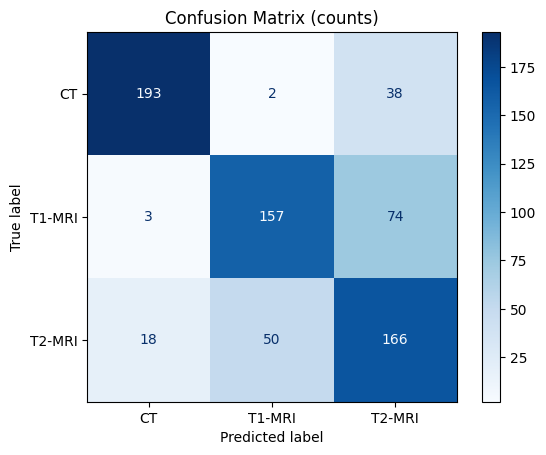

In [38]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- Collect predictions & true labels ----
y_true_chunks, y_pred_chunks = [], []
teacher.eval()   # or any model you want
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        logits = teacher(x)
        preds = torch.argmax(logits, dim=1)
        y_true_chunks.append(y.cpu().numpy())
        y_pred_chunks.append(preds.cpu().numpy())

y_true = np.concatenate(y_true_chunks)
y_pred = np.concatenate(y_pred_chunks)

# ---- Confusion Matrix (counts) ----
class_names = ['CT', 'T1-MRI', 'T2-MRI']
cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix (counts)")
plt.show()



# Confussion Mtrix